In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedGroupKFold,
    cross_val_predict
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    log_loss
)

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
# Load the final dataset
df = pd.read_csv("dataset_model_final_new.csv")

TARGET = "priority_label"

features = [
    column for column in df.columns
    if column != TARGET
]

print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())

print("\nClass counts:")
print(df[TARGET].value_counts().sort_index())

print("\nExact duplicates:", df.duplicated().sum())

# Check that identical features do not have different labels
conflicts = (
    df.groupby(features)[TARGET]
    .nunique()
)

print(
    "Conflicting feature profiles:",
    (conflicts > 1).sum()
)

Dataset shape: (7000, 22)
Missing values: 0

Class counts:
priority_label
0    4900
1    2100
Name: count, dtype: int64

Exact duplicates: 799
Conflicting feature profiles: 0


In [3]:
df.head()

,wazuh_rule_level,rule_firedtimes,suricata_alert_flag,suricata_severity,vt_positives_ratio,fim_change_flag,interaction_level,is_suspicious_activity,has_payload_pattern,user_agent_suspicious_flag,...,is_recon_activity,audit_alert_flag,http_status,is_external_ip,multi_sensor_flag,service_type_database,service_type_honeypot,service_type_host,service_type_web,priority_label
0,3,11,0,0,0.0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,2,5,0,0,0.0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,8,9,1,3,0.0,0,1,1,0,0,...,1,0,404,0,0,0,0,0,1,1
3,5,2,0,0,0.0,0,0,1,0,0,...,0,0,400,0,0,0,0,0,1,0
4,8,5,0,0,0.0,0,1,1,1,0,...,1,0,403,1,0,0,0,0,1,1


In [5]:
TARGET = "priority_label"

feature_columns = [
    column for column in df.columns
    if column != TARGET
]

print("Class counts:")
print(df[TARGET].value_counts().sort_index())

print("\nClass percentages:")
print(
    (
        df[TARGET]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2)
)

exact_duplicates = df.duplicated().sum()

conflict_check = (
    df.groupby(
        feature_columns,
        dropna=False
    )[TARGET]
    .nunique()
)

conflicting_profiles = conflict_check[
    conflict_check > 1
]

print("\nExact duplicate rows:", exact_duplicates)
print(
    "Identical profiles with conflicting labels:",
    len(conflicting_profiles)
)

if len(conflicting_profiles) > 0:
    raise ValueError(
        "Identical feature profiles contain conflicting labels."
    )

print("Dataset validation completed successfully.")

Class counts:
priority_label
0    4900
1    2100
Name: count, dtype: int64

Class percentages:
priority_label
0    70.0
1    30.0
Name: proportion, dtype: float64

Exact duplicate rows: 799
Identical profiles with conflicting labels: 0
Dataset validation completed successfully.


In [6]:
df["profile_group"] = pd.util.hash_pandas_object(
    df[feature_columns],
    index=False
).astype(str)

X = df[feature_columns].copy()
y = df[TARGET].astype(int).copy()
groups = df["profile_group"].copy()

print("Total rows retained:", len(df))
print("Input features:", X.shape[1])
print("Unique profiles:", groups.nunique())
print("Repeated rows retained:", len(df) - groups.nunique())

Total rows retained: 7000
Input features: 21
Unique profiles: 6201
Repeated rows retained: 799


In [7]:
outer_split = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, test_idx = next(
    outer_split.split(
        X,
        y,
        groups=groups
    )
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

shared_groups = set(groups_train).intersection(
    set(groups_test)
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Total rows:", len(X_train) + len(X_test))

print("\nTraining distribution:")
print(
    (
        y_train.value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
)

print("\nTesting distribution:")
print(
    (
        y_test.value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
)

print(
    "\nDuplicate profiles shared between train and test:",
    len(shared_groups)
)

assert len(shared_groups) == 0

Training rows: 5598
Testing rows: 1402
Total rows: 7000

Training distribution:
priority_label
0    69.81
1    30.19
Name: proportion, dtype: float64

Testing distribution:
priority_label
0    70.76
1    29.24
Name: proportion, dtype: float64

Duplicate profiles shared between train and test: 0


In [8]:
base_model = RandomForestClassifier(
    random_state=42,
    bootstrap=True,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [8, 10, 12, 15],
    "min_samples_split": [4, 6],
    "min_samples_leaf": [2, 4, 6],
    "max_features": ["sqrt"],
    "class_weight": ["balanced"]
}
inner_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring="f1",
    cv=inner_cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    refit=True
)

grid_search.fit(
    X_train,
    y_train,
    groups=groups_train
)

best_model = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)

print(
    "\nBest grouped cross-validation F1:",
    round(grid_search.best_score_, 4)
)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters:
{'class_weight': 'balanced', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 150}

Best grouped cross-validation F1: 0.9532


In [9]:
# Each training row is predicted by a model
# that was not trained on that row or group
oof_probability = cross_val_predict(
    best_model,
    X_train,
    y_train,
    groups=groups_train,
    cv=inner_cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

threshold_list = [0.40, 0.45, 0.50, 0.55]

results = []

for threshold in threshold_list:

    prediction = (
        oof_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        prediction
    ).ravel()

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_train,
            prediction
        ),
        "Recall": recall_score(
            y_train,
            prediction
        ),
        "F1": f1_score(
            y_train,
            prediction
        ),
        "False Positives": fp,
        "False Negatives": fn
    })

threshold_table = pd.DataFrame(results)

display(
    threshold_table.round(4)
)

,Threshold,Precision,Recall,F1,False Positives,False Negatives
0,0.40,0.9191,0.9680,0.9429,144,54
1,0.45,0.9339,0.9621,0.9478,115,64
2,0.50,0.9469,0.9598,0.9533,91,68
3,0.55,0.9550,0.9550,0.9550,76,76


In [10]:
grid_results = pd.DataFrame(grid_search.cv_results_)

selected_columns = [
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_leaf",
    "param_max_features",
    "mean_train_score",
    "mean_test_score",
    "rank_test_score"
]

grid_summary = grid_results[selected_columns].sort_values("rank_test_score")

print("Top 10 hyperparameter combinations:")
display(grid_summary.head(10))

Top 10 hyperparameter combinations:


,param_n_estimators,param_max_depth,param_min_samples_leaf,param_max_features,mean_train_score,mean_test_score,rank_test_score
37,150,15,2,sqrt,0.968556,0.953159,1
36,100,15,2,sqrt,0.969026,0.952021,2
39,150,15,2,sqrt,0.966825,0.950219,3
38,100,15,2,sqrt,0.967396,0.950218,4
27,150,12,2,sqrt,0.957767,0.949968,5
24,100,12,2,sqrt,0.959061,0.949471,6
26,100,12,2,sqrt,0.958055,0.949119,7
25,150,12,2,sqrt,0.959265,0.948342,8
15,150,10,2,sqrt,0.951981,0.945307,9
14,100,10,2,sqrt,0.950792,0.945007,10


FINAL RESULTS AT THRESHOLD 0.5
------------------------------------------
Accuracy:       0.9700
High Precision: 0.9532
High Recall:    0.9439
High F1-score:  0.9485
ROC-AUC:        0.9930
PR-AUC:        0.9851
Log Loss:       0.1007

Classification Report:
              precision    recall  f1-score   support

         Low     0.9769    0.9808    0.9789       992
        High     0.9532    0.9439    0.9485       410

    accuracy                         0.9700      1402
   macro avg     0.9651    0.9624    0.9637      1402
weighted avg     0.9700    0.9700    0.9700      1402


False Positives: 19
False Negatives: 23


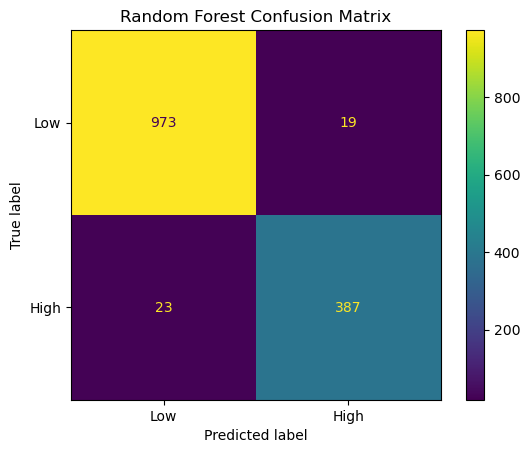

In [11]:
# Selected SOC operating threshold
THRESHOLD = 0.50

# Probabilities for the unseen test set
test_probability = best_model.predict_proba(
    X_test
)[:, 1]

# Convert probabilities into High or Low
test_prediction = (
    test_probability >= THRESHOLD
).astype(int)

accuracy = accuracy_score(
    y_test,
    test_prediction
)

precision = precision_score(
    y_test,
    test_prediction
)

recall = recall_score(
    y_test,
    test_prediction
)

f1 = f1_score(
    y_test,
    test_prediction
)

roc_auc = roc_auc_score(
    y_test,
    test_probability
)

pr_auc = average_precision_score(
    y_test,
    test_probability
)

loss = log_loss(
    y_test,
    test_probability
)


cm = confusion_matrix(
    y_test,
    test_prediction
)

tn, fp, fn, tp = cm.ravel()

print("FINAL RESULTS AT THRESHOLD 0.5")
print("-" * 42)

print(f"Accuracy:       {accuracy:.4f}")
print(f"High Precision: {precision:.4f}")
print(f"High Recall:    {recall:.4f}")
print(f"High F1-score:  {f1:.4f}")
print(f"ROC-AUC:        {roc_auc:.4f}")
print(f"PR-AUC:        {pr_auc:.4f}")
print(f"Log Loss:       {loss:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_prediction,
        target_names=["Low", "High"],
        digits=4
    )
)

print("\nFalse Positives:", fp)
print("False Negatives:", fn)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "High"]
).plot(values_format="d")

plt.title("Random Forest Confusion Matrix")
plt.show()

OVERFITTING CHECK
---------------------------------------------
Training accuracy: 0.9816
Testing accuracy:  0.9700
Accuracy gap:      0.0116

Training High F1: 0.9696
Testing High F1:  0.9485
F1 gap:           0.0211

No substantial overfitting detected.


,feature,importance
0,wazuh_rule_level,0.279889
6,interaction_level,0.126760
7,is_suspicious_activity,0.123631
8,has_payload_pattern,0.105293
11,multiple_auth_failures_flag,0.065110
16,multi_sensor_flag,0.061170
10,post_access_activity_flag,0.043226
14,http_status,0.041526
1,rule_firedtimes,0.031860
9,user_agent_suspicious_flag,0.018878


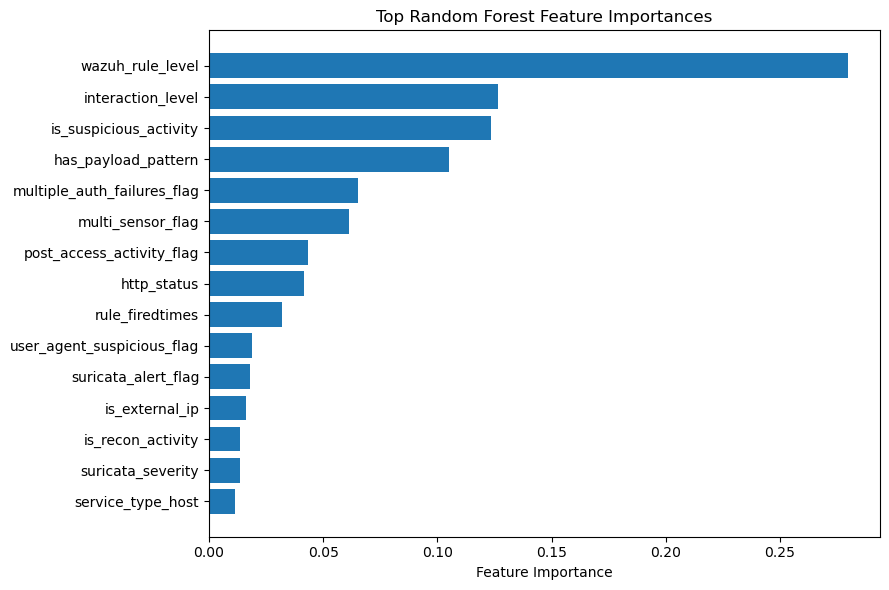

In [12]:
train_probabilities = best_model.predict_proba(
    X_train
)[:, 1]

train_predictions = (
    train_probabilities >= THRESHOLD
).astype(int)

train_accuracy = accuracy_score(
    y_train,
    train_predictions
)

train_f1 = f1_score(
    y_train,
    train_predictions,
    zero_division=0
)

accuracy_gap = train_accuracy - accuracy
f1_gap = train_f1 - f1

print("OVERFITTING CHECK")
print("-" * 45)
print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Testing accuracy:  {accuracy:.4f}")
print(f"Accuracy gap:      {accuracy_gap:.4f}")

print(f"\nTraining High F1: {train_f1:.4f}")
print(f"Testing High F1:  {f1:.4f}")
print(f"F1 gap:           {f1_gap:.4f}")

if accuracy_gap > 0.05 or f1_gap > 0.05:
    print("\nNotable overfitting detected.")

elif accuracy_gap > 0.02 or f1_gap > 0.03:
    print(
        "\nMild overfitting detected, "
        "but generalization may remain acceptable."
    )

else:
    print("\nNo substantial overfitting detected.")

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": best_model.feature_importances_
}).sort_values(
    by="importance",
    ascending=False
)

display(feature_importance.head(15))

top_features = feature_importance.head(15)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.title("Top Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [13]:
MODEL_PATH = "alert_priority_model_tuned.pkl"
THRESHOLD_PATH = "model_threshold.pkl"
FEATURES_PATH = "feature_columns.pkl"

joblib.dump(
    best_model,
    MODEL_PATH
)

joblib.dump(
    THRESHOLD,
    THRESHOLD_PATH
)

joblib.dump(
    list(X.columns),
    FEATURES_PATH
)

loaded_model = joblib.load(
    MODEL_PATH
)

loaded_threshold = joblib.load(
    THRESHOLD_PATH
)

loaded_features = joblib.load(
    FEATURES_PATH
)

verified_probabilities = loaded_model.predict_proba(
    X_test[loaded_features]
)[:, 1]

verified_predictions = (
    verified_probabilities >= loaded_threshold
).astype(int)

print("Files saved:")
print("-", MODEL_PATH)
print("-", THRESHOLD_PATH)
print("-", FEATURES_PATH)

print(
    "\nPredictions match:",
    np.array_equal(
        test_prediction,
        verified_predictions
    )
)

print(
    "Verified accuracy:",
    round(
        accuracy_score(
            y_test,
            verified_predictions
        ),
        4
    )
)

Files saved:
- alert_priority_model_tuned.pkl
- model_threshold.pkl
- feature_columns.pkl

Predictions match: True
Verified accuracy: 0.97
